# Importing

In [1]:
# %% Cell 1: Imports
from doctest import OutputChecker

import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.models import ARIMA, LinearRegressionModel, RandomForest, XGBModel

seed = 24775456

import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
import pyarrow as pa
import datetime as dt
import shap

# Load Data 

In [2]:
# %% Cell 2: Load Data
def loadData():
    df = pd.read_parquet("gafanha.parquet")
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.round("h")
    print(df.count())
    return (
        df.pivot_table(index="timestamp", columns="collection", values="value", aggfunc="median")
        .asfreq("h")
        .loc[:"2024-12-31 23:00"]
        .reset_index()
    )

df = loadData()




# %% Cell 3: Readings per day per variable - for validating the dataset only
def checkDailyCount(df):
    df_daily_counts = df.set_index("timestamp").resample("D").count()

    # quick visual: counts per year for each variable
    df_daily_counts.groupby(df_daily_counts.index.year).mean().plot(
        kind="bar", figsize=(12, 5), title="Avg daily reading count per variable, by year"
    )
    plt.ylabel("avg readings/day")
    plt.tight_layout()
    plt.show()

station       916774
timestamp     916774
collection    916774
value         916774
unit          916774
source_db     916774
date          916774
values        916774
dtype: int64


In [3]:
# %% Cell 4: Force daily, median and fill in missing values with darts package
from darts.utils.missing_values import fill_missing_values
daily = df.set_index("timestamp").resample("D").median()
daily = daily.asfreq("D")

print(daily.count())


# Set up the AQI bins for each pollutant based on the standard AQI breakpoints (European standards)
aqi_bins = {
    "PM25": [-np.inf, 10, 20, 25, 50, np.inf],
    "PM10": [-np.inf, 20, 35, 50, 100, np.inf],
    "NO2":  [-np.inf, 40, 100, 200, 400, np.inf],
    "O3":   [-np.inf, 80, 120, 180, 240, np.inf],
    "SO2":  [-np.inf, 100, 200, 350, 500, np.inf],
}
sub_idx = pd.concat(
    [pd.cut(daily[p], bins=b, labels=[1, 2, 3, 4, 5]).astype(float) for p, b in aqi_bins.items()],
    axis=1,
)
daily["AQI"] = sub_idx.max(axis=1, skipna=True)
dominant = sub_idx.dropna(how="all").idxmax(axis=1)
last_valid = daily["AQI"].last_valid_index() 
print(last_valid)

# interpolates NaNs values
daily.index = daily.index.tz_localize(None)
series = TimeSeries.from_dataframe(daily, freq="D")
series = fill_missing_values(series)

collection
Benzene          2963
CO               3010
NO               2979
NO2              2979
NOx              2979
O3               3008
PM10             2632
PM25             2626
Particles        2626
Precipitation     366
Radiation         366
SO2              2990
Temperature      2635
WindDirection    3001
WindSpeed        3001
dtype: int64
2024-12-31 00:00:00+00:00


In [4]:
print(sub_idx.notna().groupby(sub_idx.index.year).mean())
dominant.groupby(dominant.index.year).value_counts(normalize=True).unstack()

               PM25      PM10       NO2        O3       SO2
timestamp                                                  
2016       1.000000  1.000000  1.000000  1.000000  1.000000
2017       1.000000  1.000000  0.997260  1.000000  1.000000
2018       0.835616  0.835616  0.819178  0.835616  0.832877
2019       1.000000  1.000000  0.994521  0.989041  0.975342
2020       0.972678  0.991803  0.948087  0.991803  0.991803
2021       0.980822  0.978082  1.000000  1.000000  1.000000
2022       1.000000  1.000000  0.994521  1.000000  0.986301
2023       0.983562  0.983562  0.983562  1.000000  0.986301
2024       0.000000  0.000000  1.000000  1.000000  0.994536


,NO2,O3,PM10,PM25
timestamp,,,,
2016,NaN,0.013072,0.346405,0.640523
2017,NaN,0.027397,0.405479,0.567123
2018,NaN,0.026230,0.767213,0.206557
2019,NaN,0.021918,0.536986,0.441096
2020,NaN,0.071429,0.109890,0.818681
2021,0.019178,0.082192,0.082192,0.816438
2022,NaN,0.032877,0.060274,0.906849
2023,0.005479,0.095890,0.041096,0.857534
2024,0.770492,0.229508,NaN,NaN


# Set up and prepare for training 3 XGBoost Models

***Scaler does have access to the full history of covariates, so thyat might lead to a risk of dataleak, but without it, the LR will crash due to missing values from the variables***

In [5]:
# %% Cell 5: Set targets and covariates
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import StandardScaler

target = series["AQI"]
# NaN -> 0 for covariates, as the scaler cannot handle NaN values
covariates = Scaler(StandardScaler()).fit_transform(
    series.drop_columns(["AQI"]).map(lambda x: np.nan_to_num(x)))

In [29]:
# %% Cell 6: generic per-period pipeline
import optuna
from darts.metrics import rmse, mae, mape

def run_period(target, covariates, model_cls, param_space, fixed_param, n_trials=500, params=None):

    # Split the data into training, validation, and test sets
    y_train, y_temp = target.split_before(0.6)
    y_val, y_test = y_temp.split_before(0.5)
    x_train, x_temp = covariates.split_before(0.6)
    x_val, x_test = x_temp.split_before(0.5)

    # Tune with Optuna only if no params were given
    if params is None:
        def findParam(trial):
            p = {name: fn(trial) for name, fn in param_space.items()}
            model = model_cls(**p, **fixed_param)
            model.fit(y_train, past_covariates=x_train)
            preds = model.historical_forecasts(
                series=y_train.append(y_val), past_covariates=x_train.append(x_val),
                start=y_val.start_time(), forecast_horizon=1, stride=1,
                retrain=False, last_points_only=True, verbose=False,
            ).map(lambda x: np.round(x))
            return rmse(y_val, preds), mae(y_val, preds), mape(y_val, preds)

        # Minimise all three metrics (RMSE, MAE, MAPE) simultaneously
        study = optuna.create_study(directions=["minimize"] * 3,
                                    sampler=optuna.samplers.TPESampler(seed=seed))
        study.optimize(findParam, n_trials=n_trials, show_progress_bar=True)

        vals = np.array([t.values for t in study.best_trials])
        best = study.best_trials[np.argmin((vals / vals.min(axis=0)).sum(axis=1))]
        params = best.params

    y_fit, x_fit = y_train.append(y_val), x_train.append(x_val)
    test_pred = model_cls(**params, **fixed_param).historical_forecasts(
        series=y_fit.append(y_test), past_covariates=x_fit.append(x_test),
        start=y_test.start_time(), forecast_horizon=1, stride=1,
        retrain=True, train_length=None, last_points_only=True, verbose=False,
    ).map(lambda x: np.clip(np.round(x), 1, 5))

    # naive = TimeSeries.from_times_and_values(
    #     y_test.time_index, target.to_series().shift(1).loc[y_test.time_index].values)

    # Fit the final model on the combined training and validation sets - for SHAP analysis and feature importance
    model = model_cls(**params, **fixed_param).fit(y_fit, past_covariates=x_fit)

    return dict(
        model=model, params=params, y=target, x=covariates, y_test=y_test, x_test=x_test, test_pred=test_pred,
        model_metrics=(rmse(y_test, test_pred), mae(y_test, test_pred), mape(y_test, test_pred)),
        # naive_metrics=(rmse(y_test, naive), mae(y_test, naive), mape(y_test, naive)),
        sizes=(len(y_train), len(y_val), len(y_test)),
    )

# For Each of the Periods

### Config the models - run search

In [30]:
# %% Cell 7: Model Config
import joblib

lr_fixed = dict(lags=7, lags_past_covariates=7, output_chunk_length=1)

# 3 periods: pre, during, post
bounds = {"pre":    (None, "2020-02-29"),
          "during": ("2020-03-01", "2021-04-30"),
          "post":   ("2021-05-01", None)}

### Activate the training here

In [31]:
results = {}
for name, (s, e) in bounds.items():
    lo = pd.Timestamp(s) if s else target.start_time()
    hi = pd.Timestamp(e) if e else target.end_time()
    results[name] = run_period(target.slice(lo, hi), covariates.slice(lo, hi), LinearRegressionModel, None, lr_fixed, params={})
    r = results[name]
    print(name, r["sizes"], "model", r["model_metrics"])
    r["model"].save(f"lr_aqi_{name}.pkl")
joblib.dump(results, "results_lr.pkl")

pre (784, 261, 263) model (np.float64(0.8935765705592731), np.float64(0.6083650190114068), np.float64(40.23447401774398))
during (255, 85, 86) model (np.float64(0.9276125895432153), np.float64(0.6511627906976745), np.float64(33.64341085271318))
post (804, 268, 269) model (np.float64(0.499069766636149), np.float64(0.241635687732342), np.float64(20.074349442379184))


['results_lr.pkl']

# Cross Validation between models

### Load the models

In [33]:
results = joblib.load("results_lr.pkl")

In [34]:
# %% Cell 8: cross-evaluation
def score(model, y_w):
    end = y_w.end_time()
    p = model.historical_forecasts(
        series=target.slice(target.start_time(), end),
        past_covariates=covariates.slice(covariates.start_time(), end),
        start=y_w.start_time(), forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False,
    ).map(lambda x: np.clip(np.round(x), 1, 5))
    return rmse(y_w, p), mae(y_w, p)

cross = pd.DataFrame(
    {test: {f"{m}-model": score(results[m]["model"], results[test]["y_test"])[0]
            for m in results}
     for test in results}
).round(3)
cross.index.name, cross.columns.name = "model", "test window (RMSE)"
print(cross)

test window (RMSE)    pre  during   post
model                                   
pre-model           0.885   0.909  0.695
during-model        1.008   0.889  0.811
post-model          0.935   0.921  1.838


# Report, SHAP and other analysis visualisation

In [16]:
# %% Cell 9: report
report = pd.DataFrame([
    dict(period=name, model="lr", rmse=r["model_metrics"][0], mae=r["model_metrics"][1],
         mape=r["model_metrics"][2], **dict(zip(("train", "val", "test"), r["sizes"])))
    for name, r in results.items()
])
print(report.round(3).to_string(index=False))
report.to_csv("report_metrics_lr.csv", index=False)

period model  rmse   mae   mape  train  val  test
   pre    lr 0.894 0.608 40.234    784  261   263
during    lr 0.928 0.651 33.643    255   85    86
  post    lr 0.506 0.249 20.818    804  268   269


### LR Coefficient

['AQI_target_lag-7', 'AQI_target_lag-6', 'AQI_target_lag-5', 'AQI_target_lag-4', 'AQI_target_lag-3', 'AQI_target_lag-2', 'AQI_target_lag-1', 'Benzene_pastcov_lag-7', 'CO_pastcov_lag-7', 'NO_pastcov_lag-7', 'NO2_pastcov_lag-7', 'NOx_pastcov_lag-7', 'O3_pastcov_lag-7', 'PM10_pastcov_lag-7', 'PM25_pastcov_lag-7', 'Particles_pastcov_lag-7', 'Precipitation_pastcov_lag-7', 'Radiation_pastcov_lag-7', 'SO2_pastcov_lag-7', 'Temperature_pastcov_lag-7', 'WindDirection_pastcov_lag-7', 'WindSpeed_pastcov_lag-7', 'Benzene_pastcov_lag-6', 'CO_pastcov_lag-6', 'NO_pastcov_lag-6', 'NO2_pastcov_lag-6', 'NOx_pastcov_lag-6', 'O3_pastcov_lag-6', 'PM10_pastcov_lag-6', 'PM25_pastcov_lag-6', 'Particles_pastcov_lag-6', 'Precipitation_pastcov_lag-6', 'Radiation_pastcov_lag-6', 'SO2_pastcov_lag-6', 'Temperature_pastcov_lag-6', 'WindDirection_pastcov_lag-6', 'WindSpeed_pastcov_lag-6', 'Benzene_pastcov_lag-5', 'CO_pastcov_lag-5', 'NO_pastcov_lag-5', 'NO2_pastcov_lag-5', 'NOx_pastcov_lag-5', 'O3_pastcov_lag-5', 'PM1

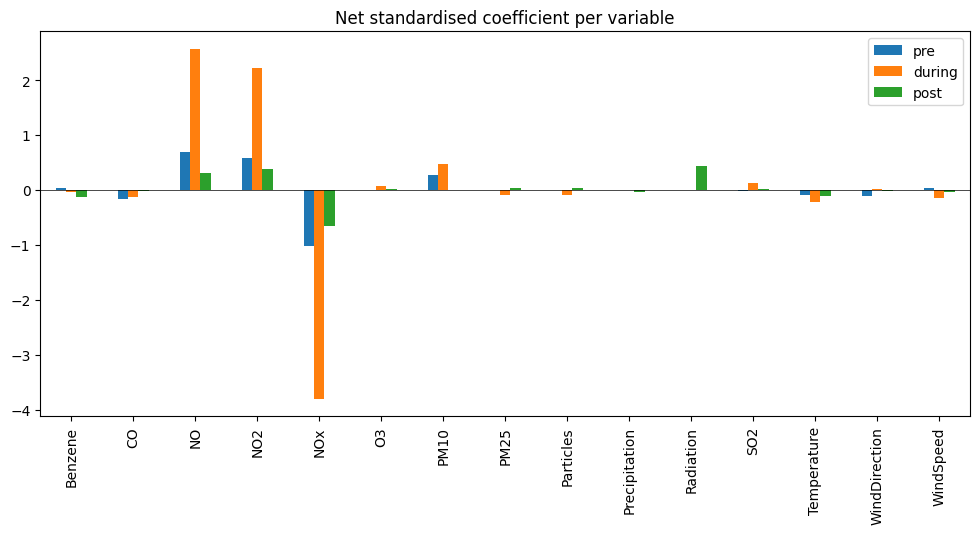

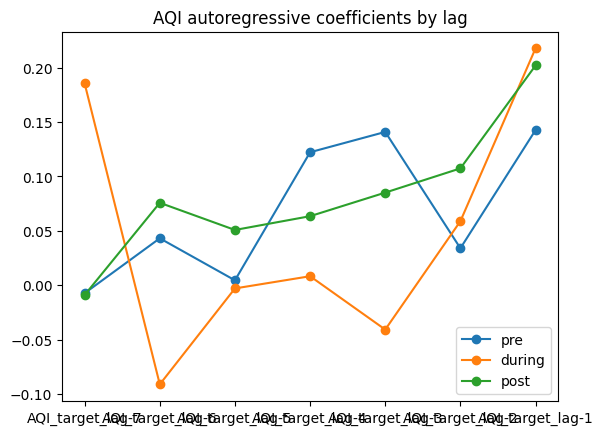

In [20]:
# %% Cell 9b: LR coefficients
import re


def coefs(m):
    return pd.Series(m.model.coef_.ravel(), index=m.lagged_feature_names)

coef = pd.DataFrame({n: coefs(r["model"]) for n, r in results.items()})
print(coef.index.tolist())   # check names match the regex

strip = lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)
net = coef.groupby(strip).sum().drop("AQI")
net.plot.bar(figsize=(12, 5), title="Net standardised coefficient per variable")
plt.axhline(0, color="k", lw=.5)
plt.show()

coef.filter(like="AQI_target", axis=0).plot(marker="o", title="AQI autoregressive coefficients by lag")
plt.show()

### 1 week and 1 month performance check for each model

The post test window is entirely 2024, when PM10/PM25 are missing, so AQI is built from NO2/O3/SO2 only. The post RMSE at 1, 7 and 30 days therefore measures a different target from pre and during. It isn't comparable across periods, and no code change fixes that. Report post separately or footnote it.

In [39]:
def horizon_scores(h):
    cov = covariates.shift(h - 1)
    tgt = target.slice_intersect(cov)
    cov = cov.slice_intersect(tgt)
    out = {}
    for name, (s, e) in bounds.items():
        lo = pd.Timestamp(s) if s else tgt.start_time()
        hi = pd.Timestamp(e) if e else tgt.end_time()
        y, x = tgt.slice(lo, hi), cov.slice(lo, hi)
        y_test = results[name]["y_test"]
        p = LinearRegressionModel(**lr_fixed).historical_forecasts(
            series=y, past_covariates=x, start=y_test.start_time(),
            forecast_horizon=h, stride=1, retrain=True, train_length=None,
            last_points_only=True, verbose=False).map(lambda v: np.round(v))
        out[name] = rmse(y_test.slice_intersect(p), p)
    return pd.Series(out)
print(pd.DataFrame({f"{h}d": horizon_scores(h) for h in (1, 7, 30)}).round(3))

           1d     7d    30d
pre     0.894  1.057  1.130
during  0.928  1.173  1.284
post    0.506  0.773  1.348


### Variable impact on decision for each period

['AQI', 'Benzene', 'CO', 'NO', 'NO2', 'NOx', 'O3', 'PM10', 'PM25', 'Particles', 'Precipitation', 'Radiation', 'SO2', 'Temperature', 'WindDirection', 'WindSpeed']


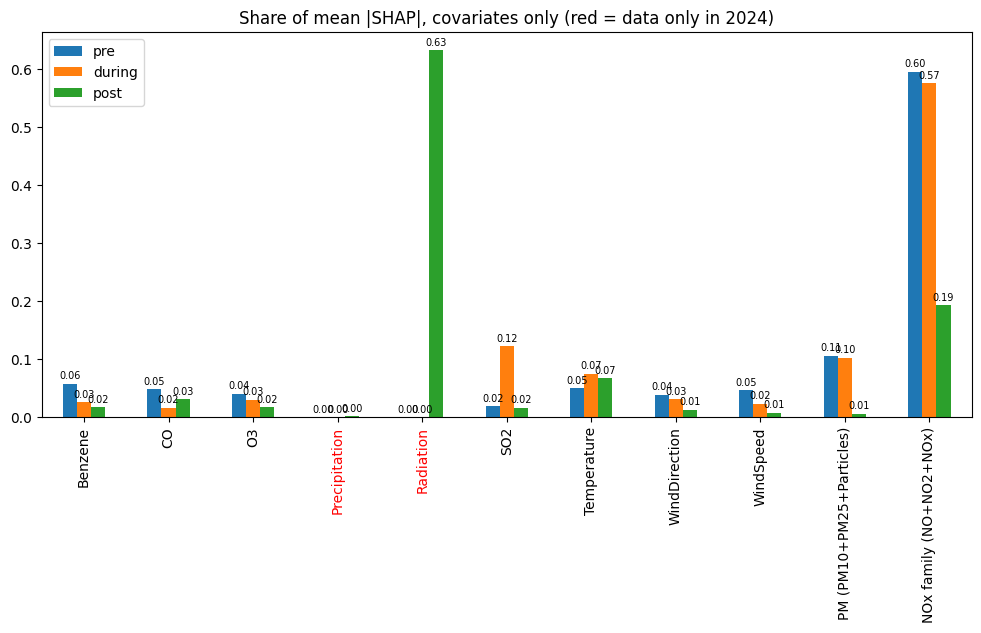

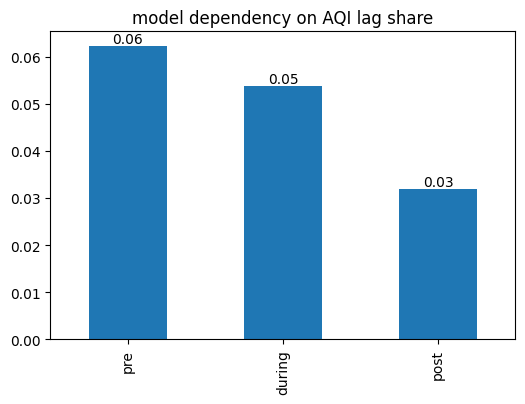

Radiation/Precipitation have data only in 2024, the same year PM10/PM25 vanish and AQI is built from NO2/O3/SO2 only. In 'post' they act as a proxy for that regime, so their share (and the post PM/NOx shares) is not a physical effect.


In [53]:
# %% Cell 10: SHAP per period
import re
from darts.explainability import ShapExplainer
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("shap").setLevel(logging.ERROR)


import logging
logging.getLogger("darts").setLevel(logging.ERROR)



def var_importance(r):
    res = ShapExplainer(r["model"]).explain(
        foreground_series=r["y"], foreground_past_covariates=r["x"])
    sv = res.get_explanation(horizon=1, component="AQI").to_dataframe()
    
    # mean |SHAP| on test days
    sv = sv.loc[r["y_test"].time_index].abs().mean()      
    return sv.groupby(lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)).sum()

imp = pd.DataFrame({name: var_importance(r) for name, r in results.items()})

# check names match the regex
print(imp.index.tolist())      

# Grouping variables into families for better visualisation
groups = {"PM (PM10+PM25+Particles)": ["PM10", "PM25", "Particles"],
          "NOx family (NO+NO2+NOx)": ["NO", "NO2", "NOx"]}

def grouped(imp):
    g = imp.drop("AQI")
    for name, cols in groups.items():
        g.loc[name] = g.loc[cols].sum()
        g = g.drop(cols)
    return g / g.sum()


# Plot the graphs
share = grouped(imp)
ax = share.plot.bar(figsize=(12, 5), title="Share of mean |SHAP|, covariates only")
for t in ax.get_xticklabels():
    if t.get_text() in ("Radiation", "Precipitation"):
        t.set_color("red")
ax.set_title(ax.get_title() + " (red = data only in 2024)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()

ax = (imp.loc["AQI"] / imp.sum()).plot.bar(figsize=(6, 4), title="model dependency on AQI lag share")
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.show()
print("Radiation/Precipitation have data only in 2024, the same year PM10/PM25 vanish and AQI is built from NO2/O3/SO2 only. "
      "In 'post' they act as a proxy for that regime, so their share (and the post PM/NOx shares) is not a physical effect.")

### Tested variable impacts of 3 models in same period

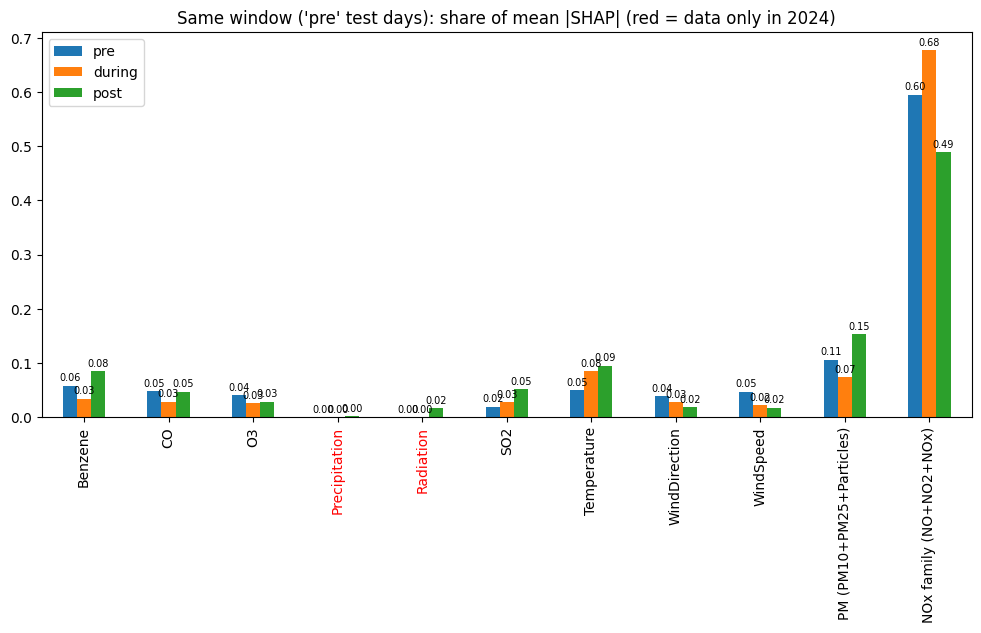

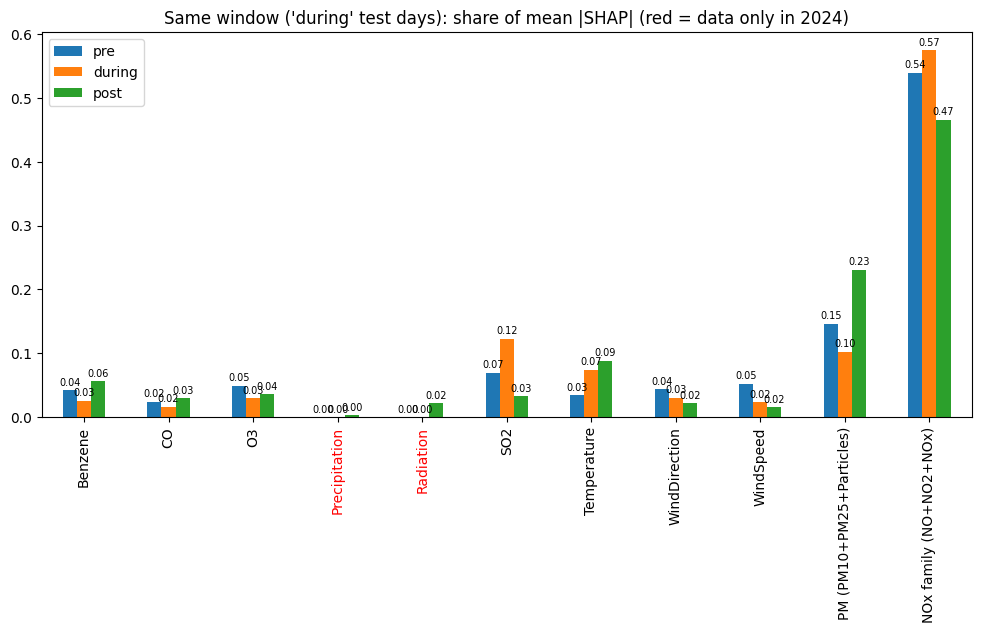

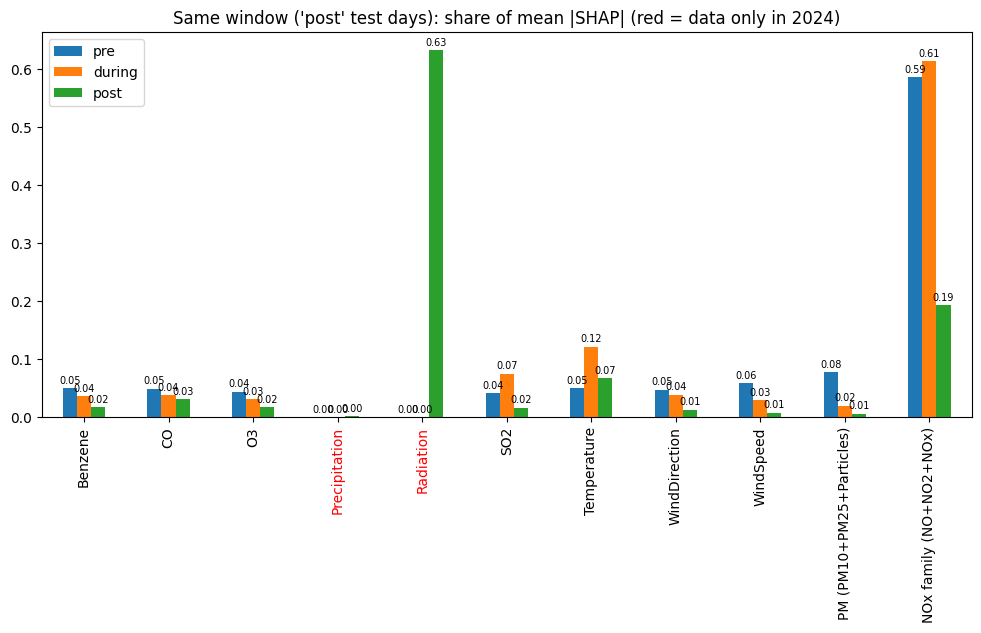

In [47]:
# %% Cell 12: SHAP, all 3 models on the same window
def var_importance_on(model, y_w, days=14):
    lo, hi = y_w.start_time() - pd.Timedelta(days=days), y_w.end_time()
    res = ShapExplainer(model).explain(
        foreground_series=target.slice(lo, hi),
        foreground_past_covariates=covariates.slice(lo, hi))
    sv = res.get_explanation(horizon=1, component="AQI").to_dataframe()
    sv = sv.loc[y_w.time_index].abs().mean()
    return sv.groupby(lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)).sum()

# Plot the graphs 
# pre graph
y_w = results["pre"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for t in ax.get_xticklabels():
    if t.get_text() in ("Radiation", "Precipitation"):
        t.set_color("red")
ax.set_title(ax.get_title() + " (red = data only in 2024)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()

# during graph
y_w = results["during"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for t in ax.get_xticklabels():
    if t.get_text() in ("Radiation", "Precipitation"):
        t.set_color("red")
ax.set_title(ax.get_title() + " (red = data only in 2024)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()

# post graph
y_w = results["post"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for t in ax.get_xticklabels():
    if t.get_text() in ("Radiation", "Precipitation"):
        t.set_color("red")
ax.set_title(ax.get_title() + " (red = data only in 2024)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()

### Beeswarm visualisation of variable impact

Note: Each node is sum of 7 lags = `SUM(coef x (x - mean))` over 1 to 7 lags, position = `coef x (value - mean)`. Color = lag 1. Spreading = `|coef| x std of feature`

AQI: blue on the left, red on the right. Yesterday's AQI high pushes today's prediction up, which is persistence and what you'd expect.
NOx and NO2 point opposite ways: NOx low sits on the right and NO2 high sits on the right. NOx is roughly NO + NO2, so LR is offsetting them against each other. This is the collinearity artefact from before. Don't read NOx and NO2 individually as "NOx lowers AQI". Read the NOx family as a whole, as you already do in grouped().
Radiation and Precipitation: flat at zero, as expected from the missing data.

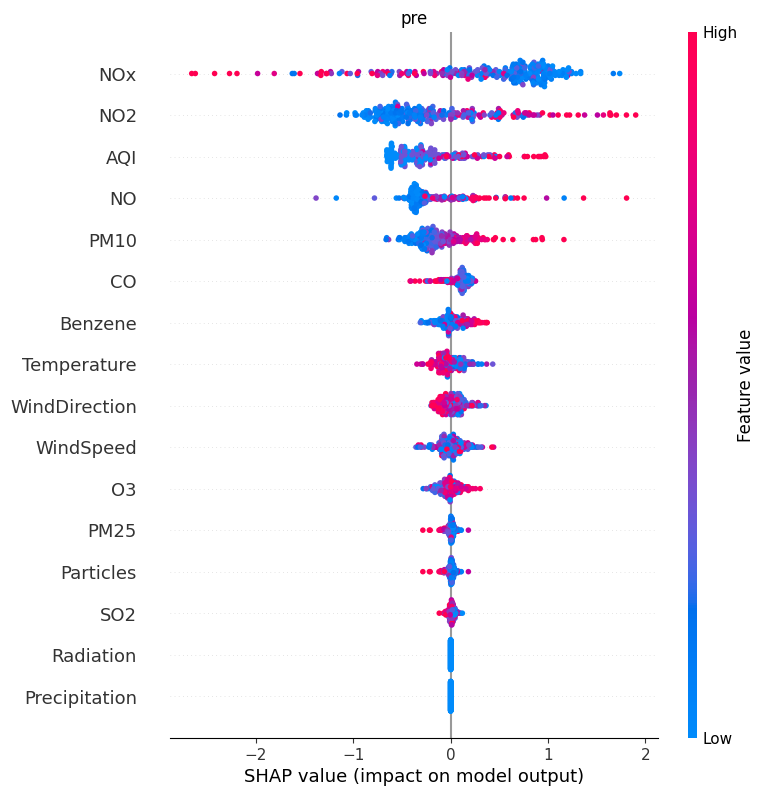

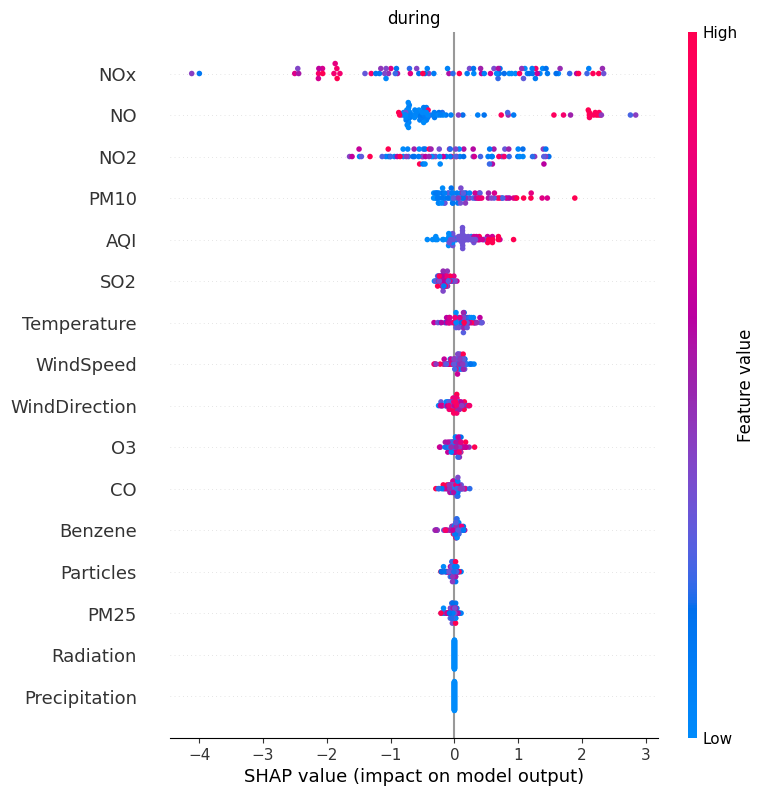

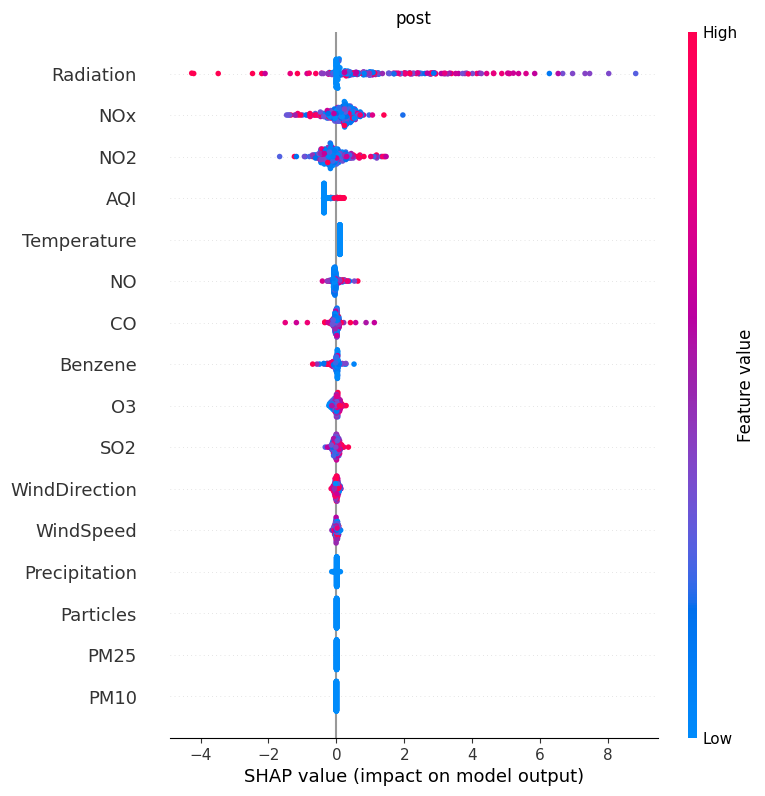

In [24]:
def beeswarm(r):
    res = ShapExplainer(r["model"]).explain(
        foreground_series=r["y"], foreground_past_covariates=r["x"])
    idx = r["y_test"].time_index
    sv = res.get_explanation(horizon=1, component="AQI").to_dataframe().loc[idx]
    fv = res.get_feature_values(horizon=1, component="AQI").to_dataframe().loc[idx]
    strip = lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)

    # Group the SHAP values and feature values by variable name (removing the lag suffix)
    sv = sv.T.groupby(strip).sum().T
    # sv = sv.filter(regex=r"_lag-1$").rename(columns=strip)
    fv = fv.filter(regex=r"_lag-1$").rename(columns=strip)[sv.columns]
    return sv, fv

for name, r in results.items():
    sv, fv = beeswarm(r)
    shap.summary_plot(sv.values, fv, show=False)
    plt.title(name)
    plt.show()

### Line graph for models' prediction vs actual data

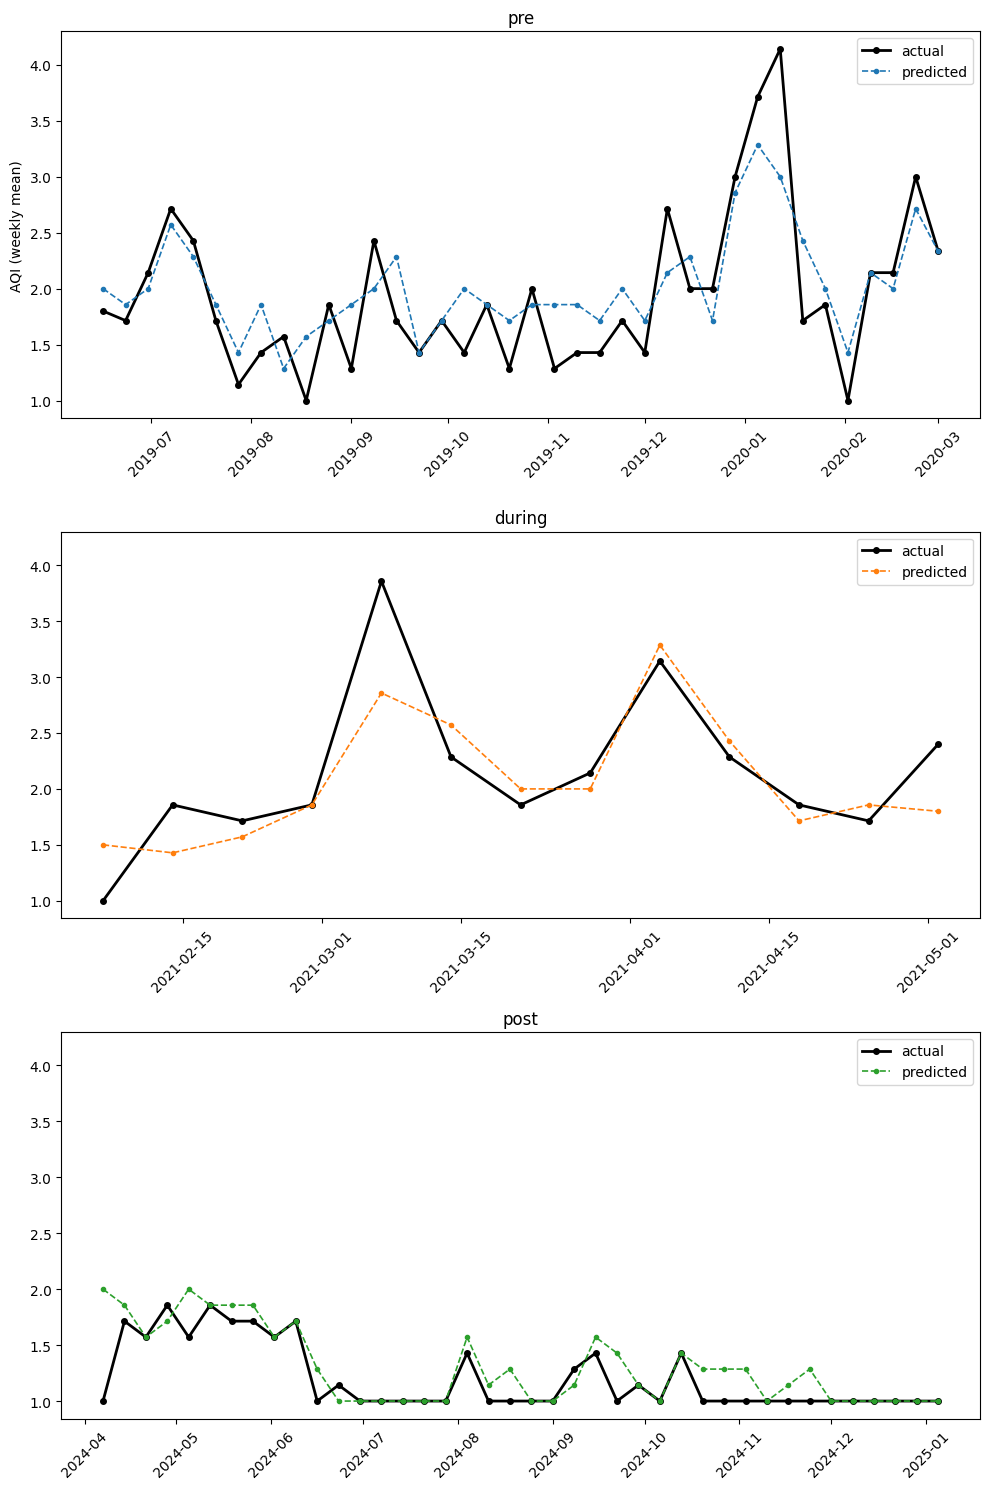

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharey=True)
colors = dict(pre="tab:blue", during="tab:orange", post="tab:green")

for ax, (name, r) in zip(axes, results.items()):
    actual_w = r["y_test"].to_series().resample("W").mean()
    pred_w = r["test_pred"].to_series().resample("W").mean()

    ax.plot(actual_w.index, actual_w.values, color="black", lw=2, marker="o", markersize=4, label="actual", zorder=2)
    ax.plot(pred_w.index, pred_w.values, color=colors[name], lw=1.2, marker="o", markersize=3,
        linestyle="--", label="predicted", zorder=3)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

    

axes[0].set_ylabel("AQI (weekly mean)")
plt.tight_layout()
plt.show()